In [1]:
import torch
import matplotlib.pyplot as plt
import matplotlib.axes as axis
import numpy as np
import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import v2
from torch.utils.data import DataLoader
import torch.nn as nn
from torchinfo import summary
import statistics
import csv

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
all, middle_region, southern_region, northern_region = ([] for _ in range(4))
unassigned = 0
with open('embedding_dataset.csv', 'r') as csvfile:
    reader = csv.reader(csvfile)
    next(reader) #skips first line of csv with headers
    for line in reader:
        match line[4]:
            case 'Eastern Temperate Forests':
                middle_region.append(line)
                all.append(line)
            case 'Northwestern Forested Mountains':
                northern_region.append(line)
                all.append(line)
            case 'Temperate Sierras':
                southern_region.append(line)
                all.append(line)
            case 'Great Plains':
                middle_region.append(line)
                all.append(line)
            case 'North American Deserts':
                southern_region.append(line)
                all.append(line)
            case 'Northern Forests':
                northern_region.append(line)
                all.append(line)
            case 'Mediterranean California':
                southern_region.append(line)
                all.append(line)
            case 'Marine West Coast Forests':
                northern_region.append(line)
                all.append(line)
            case 'Tropical Humid Forests':
                southern_region.append(line)
                all.append(line)
            case 'Southern Semi-Arid Highlands':
                northern_region.append(line)
                all.append(line)
            case _:
                all.append(line)
                unassigned += 1
                # print('unplanned classification')

In [4]:
length = len(all)
print(len(northern_region))
print(len(middle_region))
print(len(southern_region))
print(unassigned)

13076
24619
11670
262


In [5]:
genus_toint_dict = {}
species_toint_dict = {}
family_toint_dict = {}
location_toint_dict = {}
genus_tostring_dict = {}
species_tostring_dict = {}
family_tostring_dict = {}
location_tostring_dict = {}

fencode = 0
gencode = 0
sencode = 0
lencode = 0

for entry in all:
    if not entry[0] in family_toint_dict:
        family_toint_dict[entry[0]] = fencode
        family_tostring_dict[fencode] = entry[0]
        fencode += 1
    if not entry[1] in genus_toint_dict:
        genus_toint_dict[entry[1]] = gencode
        genus_tostring_dict[gencode] = entry[1]
        gencode += 1
    if not entry[2] in species_toint_dict:
        species_toint_dict[entry[2]] = sencode
        species_tostring_dict[sencode] = entry[2]
        sencode += 1
    if not entry[4] in location_toint_dict:
        location_toint_dict[entry[4]] = lencode
        location_tostring_dict[lencode] = entry[4]
        lencode += 1
print(len(location_toint_dict))
print(len(genus_toint_dict))
print(len(species_toint_dict))
print(len(family_toint_dict))


11
44
242
5


In [6]:
def encode(dataset):
    family = []
    genus = []
    location = []
    species = []
    year = []
    embeddings_tensor = torch.zeros(len(dataset), 64)
    for i, entry in enumerate(dataset):
        family.append(family_toint_dict[entry[0]])
        genus.append(genus_toint_dict[entry[1]])
        species.append(species_toint_dict[entry[2]])
        year.append(int(entry[3]))
        location.append(location_toint_dict[entry[4]])
        embeddings_tensor[i] = torch.tensor(list(map(float, entry[6:])))

    family_tensor = torch.tensor(family)
    genus_tensor = torch.tensor(genus)
    species_tensor = torch.tensor(species)
    location_tensor = torch.tensor(location)
    year_tensor = torch.tensor(year)

    return family_tensor, genus_tensor, species_tensor, location_tensor, year_tensor, embeddings_tensor

In [7]:
a_family_tensor, a_genus_tensor, a_species_tensor, a_location_tensor, a_year_tensor, a_embeddings_tensor = encode(all)
n_family_tensor, n_genus_tensor, n_species_tensor, n_location_tensor, n_year_tensor, n_embeddings_tensor = encode(northern_region)
m_family_tensor, m_genus_tensor, m_species_tensor, m_location_tensor, m_year_tensor, m_embeddings_tensor = encode(middle_region)
s_family_tensor, s_genus_tensor, s_species_tensor, s_location_tensor, s_year_tensor, s_embeddings_tensor = encode(southern_region)

In [ ]:
species_weight = np.array([0.0]*len(species_toint_dict))
label_count = len(species_toint_dict)
for entry in m_species_tensor:
    species_weight[entry] += 1.0

species_weight = torch.tensor(species_weight/length).to(device)

In [ ]:
class embed_dataset(torch.utils.data.Dataset):
    def __init__(self, family, genus, species, location, year, embeddings):
        self.family = family
        self.genus = genus
        self.location = location
        self.year = year
        self.species = species
        self.embeddings = embeddings

    def __len__(self):
        return len(self.embeddings)

    def __getitem__(self, idx):
        family = self.family[idx]
        genus = self.genus[idx]
        location = self.location[idx]
        species = self.species[idx]
        label = torch.zeros(len(species_weight))
        label[species] = 1
        target = species
        year = self.year[idx]
        embedding = self.embeddings[idx]
        return label, embedding, target


# Create dataset splits
# Set up dataloader for batches
batch_size = 1
a_train_dataset = embed_dataset(a_family_tensor, a_genus_tensor, a_species_tensor, a_location_tensor, a_year_tensor, a_embeddings_tensor)
a_train_dataloader = DataLoader(a_train_dataset, batch_size=batch_size, shuffle=True)

n_train_dataset = embed_dataset(n_family_tensor, n_genus_tensor, n_species_tensor, n_location_tensor, n_year_tensor, n_embeddings_tensor)
n_train_dataloader = DataLoader(n_train_dataset, batch_size=batch_size, shuffle=True)

m_train_dataset = embed_dataset(m_family_tensor, m_genus_tensor, m_species_tensor, m_location_tensor, m_year_tensor, m_embeddings_tensor)
m_train_dataloader = DataLoader(m_train_dataset, batch_size=batch_size, shuffle=True)

s_train_dataset = embed_dataset(s_family_tensor, s_genus_tensor, s_species_tensor, s_location_tensor, s_year_tensor, s_embeddings_tensor)
s_train_dataloader = DataLoader(s_train_dataset, batch_size=batch_size, shuffle=True)

In [10]:
#define model parameters
class TransformerModel(nn.Module):
    def __init__(self, layers=1):
        super().__init__()
        self.t1 = nn.TransformerEncoderLayer(d_model=64, nhead = 8, dim_feedforward=2048, dropout=0.1, batch_first=True)
        self.t2 = nn.TransformerEncoderLayer(d_model=64, nhead = 8, dim_feedforward=2048, dropout=0.1, batch_first=True)
        self.t3 = nn.TransformerEncoderLayer(d_model=64, nhead = 8, dim_feedforward=2048, dropout=0.1, batch_first=True)
        self.l1 = nn.Linear(64, 1024)
        self.l2 = nn.Linear(1024, label_count)
        self.relu = nn.ReLU()
        self.layers = layers
    def forward(self, embedding):
        result = self.t3(self.t2(self.t1(embedding)))
        x = self.relu(self.l1(result))
        return self.l2(x)

In [11]:
import torch.optim as optim
def training(model, learning_rate, criterion, train_dataloader):
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
    losses = []
    for epoch in range(10):
        model.train()
        total_loss = 0
        for label, embedding, target in train_dataloader:
            embedding, label = embedding.to(device), label.to(device)
            optimizer.zero_grad()
            logits = model(embedding)
            loss = criterion(logits, label)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_dataloader)
        losses.append(avg_loss)
        print(f"Epoch {epoch+1} - Loss: {avg_loss:.6f}")
    return losses

In [12]:
import torch.optim as optim
accuracies = []
labels = []
learning_rate = 2e-3

transformer_a = TransformerModel().to(device)
transformer_n = TransformerModel().to(device)
transformer_m = TransformerModel().to(device)
transformer_s = TransformerModel().to(device)


criterion = nn.BCEWithLogitsLoss(weight=genus_weight)

losses_a = training(model=transformer_a, learning_rate=learning_rate, criterion=criterion, train_dataloader=a_train_dataloader)
losses_n = training(model=transformer_n, learning_rate=learning_rate, criterion=criterion, train_dataloader=n_train_dataloader)
losses_m = training(model=transformer_m, learning_rate=learning_rate, criterion=criterion, train_dataloader=m_train_dataloader)
losses_s = training(model=transformer_s, learning_rate=learning_rate, criterion=criterion, train_dataloader=s_train_dataloader)

Epoch 1 - Loss: 0.004424
Epoch 2 - Loss: 0.004402
Epoch 3 - Loss: 0.004395
Epoch 4 - Loss: 0.004402
Epoch 5 - Loss: 0.004402
Epoch 6 - Loss: 0.004397
Epoch 7 - Loss: 0.004399
Epoch 8 - Loss: 0.004399
Epoch 9 - Loss: 0.004399
Epoch 10 - Loss: 0.004401
Epoch 1 - Loss: 0.003139
Epoch 2 - Loss: 0.003000
Epoch 3 - Loss: 0.003359
Epoch 4 - Loss: 0.003354
Epoch 5 - Loss: 0.003349
Epoch 6 - Loss: 0.003350
Epoch 7 - Loss: 0.003355
Epoch 8 - Loss: 0.003350
Epoch 9 - Loss: 0.003352
Epoch 10 - Loss: 0.003355
Epoch 1 - Loss: 0.004788
Epoch 2 - Loss: 0.004760
Epoch 3 - Loss: 0.004756
Epoch 4 - Loss: 0.004755
Epoch 5 - Loss: 0.004757
Epoch 6 - Loss: 0.004756
Epoch 7 - Loss: 0.004756
Epoch 8 - Loss: 0.004756
Epoch 9 - Loss: 0.004755
Epoch 10 - Loss: 0.004756
Epoch 1 - Loss: 0.003975
Epoch 2 - Loss: 0.003939
Epoch 3 - Loss: 0.003931
Epoch 4 - Loss: 0.003930
Epoch 5 - Loss: 0.003925
Epoch 6 - Loss: 0.003926
Epoch 7 - Loss: 0.003924
Epoch 8 - Loss: 0.003924
Epoch 9 - Loss: 0.003925
Epoch 10 - Loss: 0.003

In [17]:
def analyze(model, learning_rate, dataloader, criterion):
    count = 0
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
    with torch.no_grad():
        for label, embedding, target in dataloader:
            embedding, label, target = embedding.to(device), label.to(device), target.to(device)
            optimizer.zero_grad()
            logits = model(embedding)
            loss = criterion(logits, label)
            predict = nn.Softmax()
            prediction = predict(logits)
            if(torch.argmax(prediction) == target):
                count += 1
    print(count, len(dataloader))
    print(count/len(dataloader))
    return count/len(dataloader)

In [18]:
accuracies.append(analyze(transformer_a, learning_rate, a_train_dataloader, criterion=criterion))
accuracies.append(analyze(transformer_n, learning_rate, n_train_dataloader, criterion=criterion))
accuracies.append(analyze(transformer_m, learning_rate, m_train_dataloader, criterion=criterion))
accuracies.append(analyze(transformer_s, learning_rate, s_train_dataloader, criterion=criterion))

985 49627
0.019848066576661896
1 13076
7.647598654022637e-05
0 24619
0.0
651 11670
0.055784061696658095


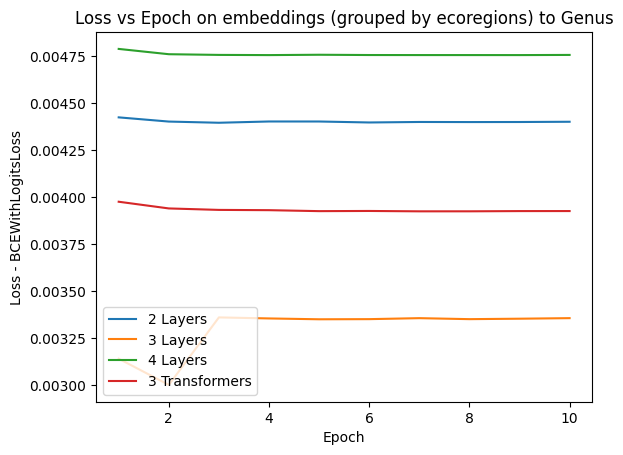

In [19]:
x = list(range(1,11))

plt.plot(x, losses_a, label = "2 Layers")
plt.plot(x, losses_n, label = "3 Layers")
plt.plot(x, losses_m, label = "4 Layers")
plt.plot(x, losses_s, label = "3 Transformers")
plt.ylabel("Loss - BCEWithLogitsLoss")
plt.xlabel("Epoch")
plt.legend()
plt.title("Loss vs Epoch on embeddings (grouped by ecoregions) to Genus")
plt.show()

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (4,) and arg 1 with shape (8,).

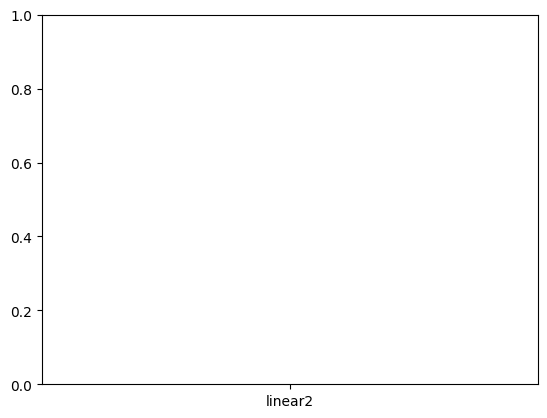

In [20]:
x = ["linear2", "linear3", "linear4", "transformer"]

fig, ax = plt.subplots()
ax.bar(x, accuracies)
ax.set_xlabel("Model")
ax.set_ylabel("Accuracy")
ax.set_ylim(bottom=0.9, top=1)
ax.set_title("Accuracies of models on embeddings (grouped by ecoregions) to Genus")